<h1 align="center">Quantiles extrêmes — hauteur de la Seine (Pont d’Austerlitz)</h1>

## Résumé

+ **Données** : hauteur journalière de la Seine à Paris (Pont d’Austerlitz), 1885–2026 (source EAUFRANCE).

+ **Objectif** : estimer des **quantiles extrêmes** (niveaux associés à des périodes de retour $T$) et discuter le **domaine d’attraction** via EVT.

+ **Méthodes** : (i) ajustements paramétriques sur le journalier (lognormale, gamma, GEV), (ii) **maxima annuels** + GEV (théorie des maxima de blocs), (iii) approche **POT** (excès au-dessus d’un seuil) via un modèle semi-paramétrique **KDE + GPD**.

+ **Points d’attention** : stationnarité (tendance/saisonnalité), dépendance temporelle (données journalières), choix du seuil $u$ et incertitude sur $\xi$.

## Plan du notebook
1. Récupération et nettoyage des données
2. Exploration (non-normalité, asymétrie)
3. Ajustements paramétriques + modèle semi-paramétrique KDE+GPD
4. EVT sur maxima annuels (GEV) + quantiles extrêmes
5. Saisonnalité (diagnostic rapide)

# 1) Récupération des données

Commençons par récupérer les données. 

Les données sont disponibles sur le site [EAUFRANCE](https://hydro.eaufrance.fr/stationhydro/F700000102/fiche) - contenant les mesures de la hauteur de la Seine sous le Pont d'Austerlitz de manière quotidienne depuis le 26 septembre 1885.

Les données sont disponibles sur EAUFRANCE (station F700000102).
Le fichier `provenance_donnees.md` permet de tracer précisément l’origine et la période de chaque fichier CSV agrégé ici.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns
import utils

In [2]:
seine_av1966 = pd.read_csv("data/EAUFRANCE-F700000109-Seine_Paris_Austerlitz-historique_av_1966-H.csv", sep=",")
seine_1966_1973 = pd.read_csv("data/EAUFRANCE-F700000110-Seine_Paris_Austerlitz-historique_1966-1973-H.csv", sep=",")
seine_1974_1989 = pd.read_csv("data/EAUFRANCE-F700000111-Seine_Paris_Austerlitz-historique_1974-1989-H.csv", sep=",")
seine_1990_2026 = pd.read_csv("data/EAUFRANCE-F700000102-Seine_Paris_Austerlitz-limini-1990-2026-H.csv", sep=",")

In [3]:
# Concaténation des DataFrames
seine = pd.concat([seine_av1966, seine_1966_1973, seine_1974_1989, seine_1990_2026], ignore_index=True)
seine.head()

,Date (TU),Date de la mesure du min/max (TU),Valeur (en m),Statut,Qualification,Méthode,Continuité
0,1885-09-26T00:00:00.000Z,1885-09-26T08:00:00.000Z,0.90,12,20,10,1
1,1885-09-27T00:00:00.000Z,1885-09-27T23:59:59.000Z,0.75,12,20,10,0
2,1885-09-28T00:00:00.000Z,1885-09-28T15:00:00.000Z,0.90,12,20,10,0
3,1885-09-29T00:00:00.000Z,1885-09-29T08:00:00.000Z,0.90,12,20,10,0
4,1885-09-30T00:00:00.000Z,1885-09-30T08:00:00.000Z,0.90,12,20,10,0


In [4]:
# Parse la date et garde uniquement les colonnes utiles
date_col = "Date (TU)" if "Date (TU)" in seine.columns else "Date"
seine[date_col] = pd.to_datetime(seine[date_col], format="%Y-%m-%dT%H:%M:%S.%fZ", errors="coerce")

seine.drop(
    columns=["Date de la mesure du min/max (TU)", "Statut", "Qualification", "Méthode", "Continuité"],
    inplace=True,
    errors="ignore",
 )
seine.rename(columns={"Valeur (en m)": "Hauteur", date_col: "Date"}, inplace=True)
seine["Hauteur"] = seine["Hauteur"].astype(float)
seine = seine[["Date", "Hauteur"]].dropna(subset=["Date", "Hauteur"]).copy()
seine = seine.sort_values("Date").reset_index(drop=True)

# Shift: utile pour ajuster des lois définies sur (0, +inf) (lognormale, gamma, ...)
SHIFT_SEINE = seine["Hauteur"].min() - 1e-6  # assure Hauteur_shifted > 0
seine["Hauteur_shifted"] = seine["Hauteur"] - SHIFT_SEINE

seine.head()

,Date,Hauteur,Hauteur_shifted
0,1885-09-26,0.90,2.150001
1,1885-09-27,0.75,2.000001
2,1885-09-28,0.90,2.150001
3,1885-09-29,0.90,2.150001
4,1885-09-30,0.90,2.150001


In [5]:
seine.describe() 

,Date,Hauteur,Hauteur_shifted
count,50926,50926.000000,5.092600e+04
mean,1956-04-11 10:36:31.697758,1.456349,2.706350e+00
min,1885-09-26 00:00:00,-1.250000,1.000000e-06
25%,1921-06-27 06:00:00,1.000000,2.250001e+00
50%,1956-05-05 12:00:00,1.150000,2.400001e+00
75%,1991-03-20 18:00:00,1.600000,2.850001e+00
max,2026-03-25 00:00:00,8.620000,9.870001e+00
std,NaN,0.794490,7.944901e-01


In [6]:
# count nan values in the 'Hauteur' column
print(seine['Hauteur'].isna().sum())

0


Nous avons plus de 130 ans de données, grâce à EAUFRANCE, ce qui nous permettra d'avoir une bonne estimation de la distribution des quantiles extrêmes.

Les données ont déjà été nettoyées et préparées. 

In [7]:
# On sauvegarde l'ensemble de la Seine :
seine.to_csv("data/EAUFRANCE-F7000001XX-Seine-complete.csv", columns=["Date", "Hauteur"], index=False, sep=";")

# 2) Exploration rapide (forme de distribution, ordres de grandeur)

In [8]:
mean, std = seine["Hauteur"].mean(), seine["Hauteur"].std()
print(f"Mean: {mean:.2f}, Std: {std:.2f}")

Mean: 1.46, Std: 0.79


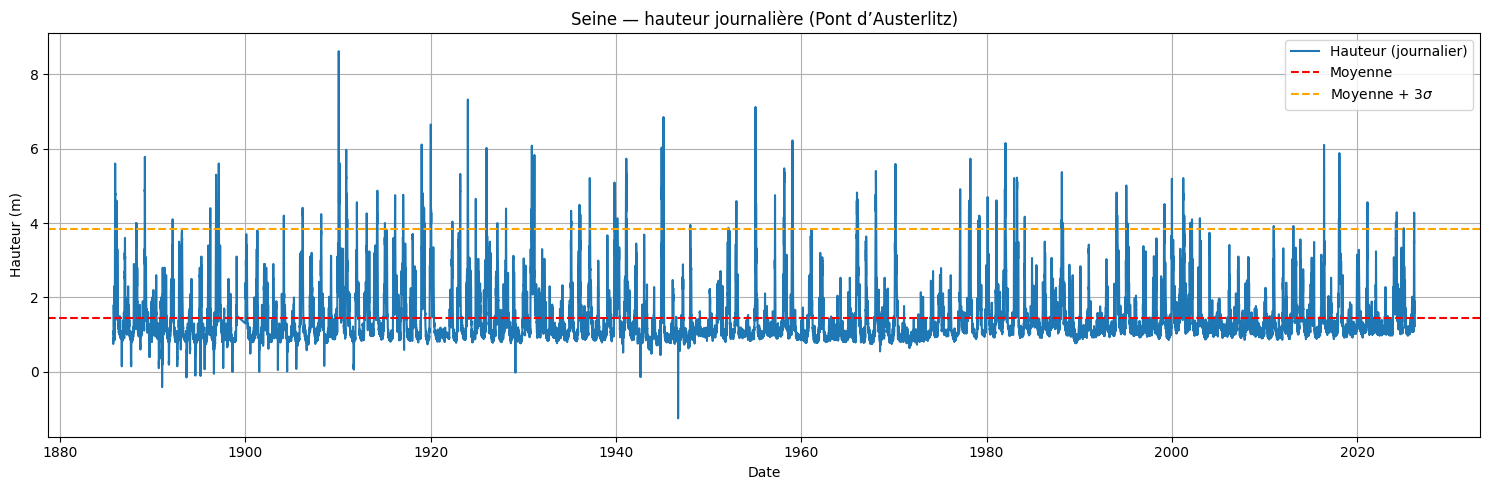

In [9]:
plt.figure(figsize=(15, 5))
plt.plot(seine["Date"], seine["Hauteur"], label="Hauteur (journalier)")

# Repères (moyenne et moyenne + 3 écarts-types)
plt.axhline(mean, color="red", linestyle="--", label="Moyenne")
plt.axhline(mean + 3 * std, color="orange", linestyle="--", label=r"Moyenne + $3\sigma$")

plt.legend()
plt.xlabel("Date")
plt.ylabel("Hauteur (m)")
plt.title("Seine — hauteur journalière (Pont d’Austerlitz)")
plt.grid(True)
plt.tight_layout()
plt.savefig("fig_01_evolution_seine.png", dpi=200)
plt.show()

In [10]:
# Date de la donnée la plus basse
min_date = seine.loc[seine["Hauteur"].idxmin(), "Date"]
print(f"Date de la donnée la plus basse: {min_date}")

Date de la donnée la plus basse: 1946-09-15 00:00:00


Le dépassement fréquent de la barre $\mu + 3\sigma$ et l’asymétrie à droite suggèrent que la distribution n’est pas gaussienne et que la queue droite est plus lourde que celle d’une normale. 

Attention : cela ne suffit pas à conclure au domaine de Fréchet ; on vérifiera le **domaine d’attraction** via l’analyse EVT (maxima de blocs / excès au-dessus d’un seuil) et le signe de l’estimateur de $\xi$.

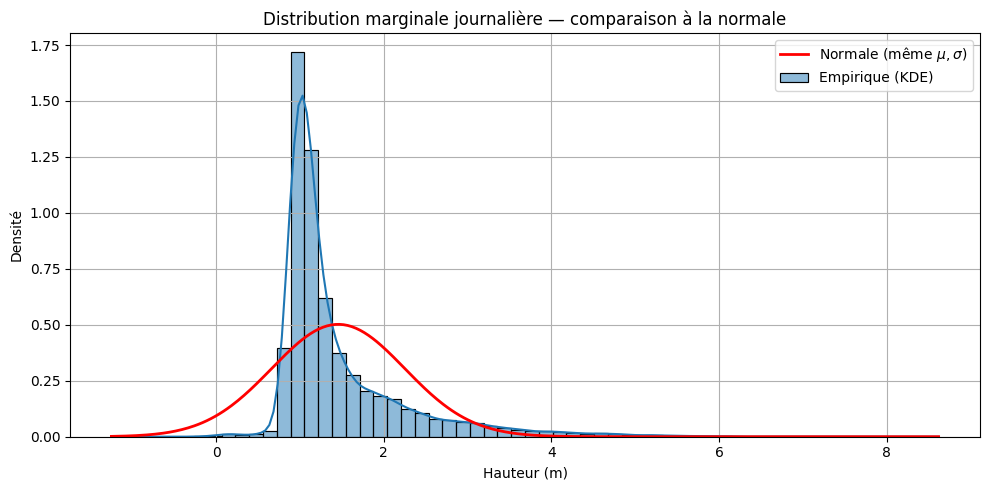

In [11]:
# Histogramme + comparaison à une normale (même moyenne/écart-type)
plt.figure(figsize=(10, 5))
sns.histplot(seine["Hauteur"], bins=60, kde=True, stat="density", label="Empirique (KDE)")

x = np.linspace(seine["Hauteur"].min(), seine["Hauteur"].max(), 400)
plt.plot(x, stats.norm.pdf(x, mean, std), color="red", lw=2, label=r"Normale (même $\mu,\sigma$)")

plt.legend()
plt.xlabel("Hauteur (m)")
plt.ylabel("Densité")
plt.title("Distribution marginale journalière — comparaison à la normale")
plt.grid(True)
plt.tight_layout()
plt.savefig("fig_02_histogramme_vs_normale.png", dpi=200)
plt.show()

# 3) Ajustements paramétriques et semi-paramétriques

In [12]:
# Fit d'une distribution lognormale - Note: we need to fit the log of the data, so we need to shift the data to be positive
shape, loc, scale = stats.lognorm.fit(seine["Hauteur_shifted"], floc=0)
print(f"Lognormal fit parameters: shape={shape:.2f}, loc={loc:.2f}, scale={scale:.2f}") 

Lognormal fit parameters: shape=0.25, loc=0.00, scale=2.62


In [13]:
# Fit gamma distribution - besoin aussi de shift pour être positif
gamma_shape, gamma_loc, gamma_scale = stats.gamma.fit(seine["Hauteur_shifted"], floc=0)
print(f"Gamma fit parameters: shape={gamma_shape:.2f}, loc={gamma_loc:.2f}, scale={gamma_scale:.2f}")

Gamma fit parameters: shape=15.40, loc=0.00, scale=0.18


In [14]:
# Fit d'une GEV distribution
gev_shape, gev_loc, gev_scale = stats.genextreme.fit(seine["Hauteur"])
print(f"GEV fit parameters: shape={gev_shape:.2f}, loc={gev_loc:.2f}, scale={gev_scale:.2f}")

GEV fit parameters: shape=-0.07, loc=1.14, scale=0.46


## Modèle semi-paramétrique : KDE adaptatif + GPD

Soit $X$ une variable aléatoire représentant la hauteur d'eau journalière, et $u > 0$ un seuil fixé. On définit le modèle par la densité mixte suivante :

$$
f(x) = \begin{cases} \dfrac{F_n(u)}{C_u} \, \hat{f}_{\text{KDE}}(x) & \text{si } x \leq u \\[10pt] \bigl(1 - F_n(u)\bigr) \cdot g_{\xi,\beta}(x - u) & \text{si } x > u \end{cases}
$$

où $F_n(u) = \mathbb{P}(X \leq u)$ est la proportion empirique des observations sous le seuil, $C_u = \int_{-\infty}^{u} \hat{f}_{\text{KDE}}(t)\, dt$ est la masse du KDE intégrée jusqu'en $u$ (facteur de normalisation), $\hat{f}_{\text{KDE}}$ est l'estimateur à noyau gaussien ajusté sur les observations $x_i \leq u$, et $g_{\xi,\beta}$ est la densité de la **loi de Pareto généralisée (GPD)** :

$$
g_{\xi,\beta}(y) = \frac{1}{\beta}\left(1 + \xi \frac{y}{\beta}\right)^{-1/\xi - 1}, \quad y > 0
$$

avec $\beta > 0$ le paramètre d'échelle et $\xi \in \mathbb{R}$ le paramètre de forme (queue lourde si $\xi > 0$, exponentielle si $\xi = 0$, queue bornée si $\xi < 0$).

**Raccordement et normalisation.** Par construction, $f$ est une densité valide : les deux branches intègrent respectivement à $F_n(u)$ et $1 - F_n(u)$, et leur somme vaut 1. La continuité au point $u$ n'est pas garantie en général, mais peut être imposée comme contrainte supplémentaire lors de l'optimisation.

**Estimation.** Les paramètres $(\xi, \beta)$ de la GPD sont estimés par **maximum de vraisemblance** sur les excès $y_i = x_i - u$ pour les $x_i > u$. Le KDE est ajusté indépendamment sur le corps $\{x_i \leq u\}$, avec une bande passante $h$ choisie par la **règle de Silverman** :

$$
h = 1.06 \, \hat{\sigma} \, n_b^{-1/5}
$$

où $\hat{\sigma}$ est l'écart-type empirique du corps et $n_b$ le nombre d'observations sous le seuil. Les deux composantes sont ainsi estimées **séparément**, ce qui évite tout compromis entre la fidélité au pic et la précision sur la queue.

In [15]:
# Fit d'une mixture - prend quelques minutes à tourner
# revient à faire un fit KDE sur la première partie des données et un fit GPD sur les données au-dessus d'un certain seuil
params_mixture_kde_gpd = utils.fit_mixture_kde_gpd(seine["Hauteur"], u_quantile=0.92)
params_mixture_kde_gpd

Seuil u = 2.700 m  (92.0% des données sous le seuil)
Bande passante KDE = 0.0534 m

=== Résultats KDE + GPD ===
  Poids corps (KDE)   w_body = 0.9201
  Poids queue (GPD)   w_tail = 0.0799
  xi   (forme GPD)           = -0.1051  → exponentielle
  beta (échelle GPD)         = 1.0082
  AIC (GPD) = 7343.1   BIC (GPD) = 7355.7
  Convergence GPD : OK


{'kde': KernelDensity(bandwidth=np.float64(0.05338740220625836)),
 'xi': np.float64(-0.10505380585340242),
 'beta': np.float64(1.008247162836252),
 'u': 2.7,
 'w_body': 0.9201485790652884,
 'w_tail': 0.07985142093471165,
 'bandwidth': np.float64(0.05338740220625836),
 'x_min': 0.01,
 'aic': np.float64(7343.0744526663375),
 'bic': np.float64(7355.693806458313),
 'gpd_success': True}

In [16]:
fit_distribution = {
    "lognormale": (shape, loc, scale),
    "gamma": (gamma_shape, gamma_loc, gamma_scale),
    "GEV": (gev_shape, gev_loc, gev_scale),
}
if "params_mixture_kde_gpd" in globals():
    fit_distribution["Mixture KDE + GPD"] = params_mixture_kde_gpd

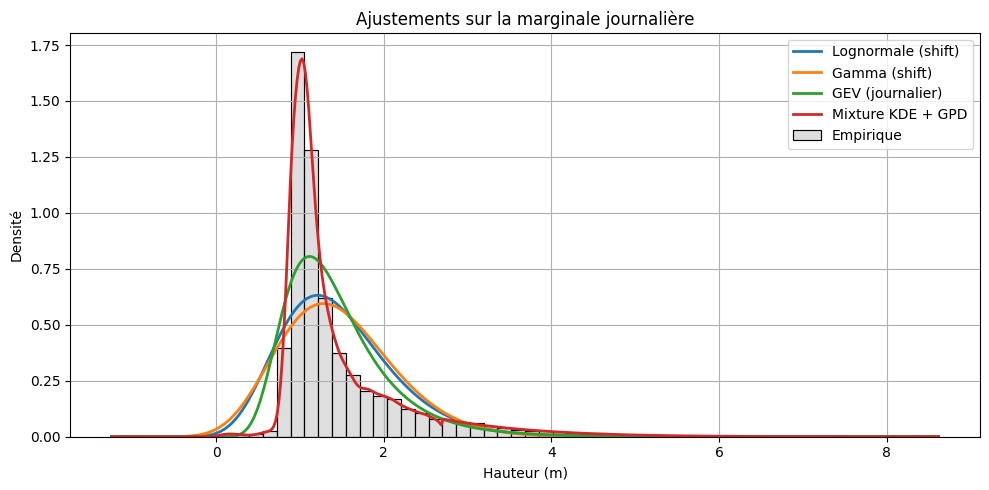

In [17]:
# Histogramme + ajustements paramétriques (sur la variable shiftée si nécessaire)
plt.figure(figsize=(10, 5))
sns.histplot(seine["Hauteur"], bins=60, stat="density", label="Empirique", color="lightgray")

x_shift = np.linspace(seine["Hauteur_shifted"].min(), seine["Hauteur_shifted"].max(), 500)
x = x_shift + SHIFT_SEINE

pdf_lognorm = stats.lognorm.pdf(x_shift, shape, loc, scale)
pdf_gamma = stats.gamma.pdf(x_shift, gamma_shape, gamma_loc, gamma_scale)
pdf_gev_daily = stats.genextreme.pdf(x, gev_shape, loc=gev_loc, scale=gev_scale)
pdf_mixture = utils.mixture_kde_gpd_pdf(x, params_mixture_kde_gpd)

plt.plot(x, pdf_lognorm, lw=2, label="Lognormale (shift)")
plt.plot(x, pdf_gamma, lw=2, label="Gamma (shift)")
plt.plot(x, pdf_gev_daily, lw=2, label="GEV (journalier)")
plt.plot(x, pdf_mixture, lw=2, label="Mixture KDE + GPD")

plt.xlabel("Hauteur (m)")
plt.ylabel("Densité")
plt.title("Ajustements sur la marginale journalière")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("fig_03_fits_marginale.png", dpi=200)
plt.show()

Les figures confirment que la loi n’est pas gaussienne (asymétrie et queue droite plus lourde qu’une normale).

En EVT, l’appartenance au domaine d’attraction (*Fréchet/Weibull/Gumbel*) se lit via le **paramètre de forme** $\xi$ : on verra plus loin ce que donnent les maxima de blocs (GEV) et, via la GPD, les excès au-dessus d’un seuil.

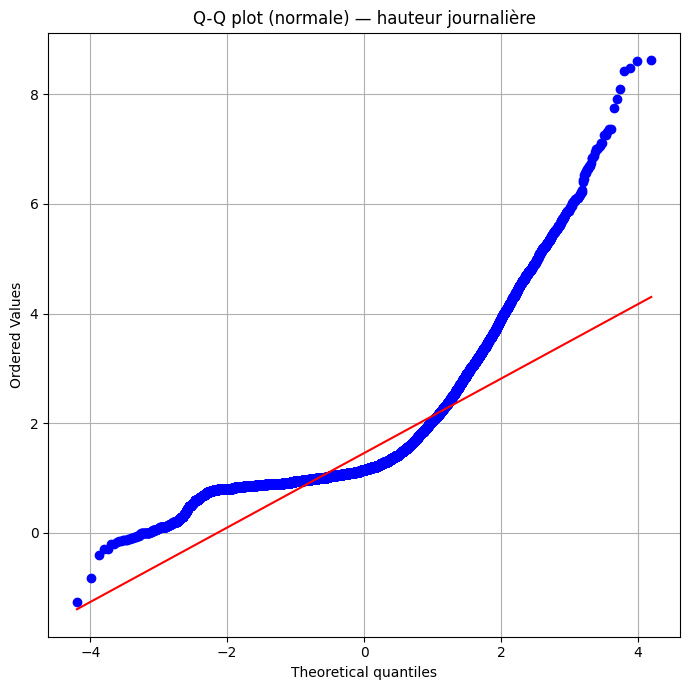

In [18]:
# Q-Q plot vs normale (diagnostic de non-normalité)
plt.figure(figsize=(7, 7))
stats.probplot(seine["Hauteur"], dist="norm", plot=plt)
plt.title("Q-Q plot (normale) — hauteur journalière")
plt.grid(True)
plt.tight_layout()
plt.savefig("fig_04_qq_normale.png", dpi=200)
plt.show()

Là aussi le Q-Q plot montre que la distribution n'est pas gaussienne, et que les données ont une queue lourde à droite. Nous allons vérifier cela dans la section suivante.

## Rappel — Lire un Q-Q plot (Quantile-Quantile)

Un **Q-Q plot** compare les quantiles observés de vos données (axe vertical) aux quantiles théoriques d’une loi de référence (axe horizontal, souvent normale ou GEV).

### Comment le lire rapidement

- **Points proches d’une droite** : la loi de référence décrit bien les données.
- **Décalage global (droite non centrée)** : différence de position (moyenne / localisation).
- **Pente différente de 1** : différence d’échelle (écart-type / dispersion).
- **Courbure en S** : asymétrie ou mauvaise forme globale de la distribution.
- **Écarts marqués aux extrémités** : problème d’ajustement dans les queues (extrêmes), point crucial en EVT.

### Interprétation des queues

- **Extrémité droite au-dessus de la droite** : queue droite plus lourde que le modèle.
- **Extrémité droite en dessous** : queue droite plus légère que le modèle.
- Même logique à gauche pour la queue gauche.

### Dans ce notebook (maxima annuels + GEV)

- Si les points restent proches de la droite, l’ajustement GEV est cohérent.
- Les écarts en haut à droite indiquent une possible sous/surestimation des **quantiles extrêmes** (périodes de retour élevées).
- Un Q-Q plot aide au diagnostic visuel, mais doit être complété par des critères quantitatifs (AIC/BIC, IC des paramètres, tests de stabilité).

# 4) EVT : maxima de blocs (GEV) et quantiles extrêmes

Effectuons un fit des données à une distribution GEV (Generalized Extreme Value) pour estimer les paramètres de la loi limite des **maxima de blocs**. Pour cela, nous allons utiliser la méthode `fit` de `scipy.stats.genextreme`.

Dans la suite on travaille sur les **maxima annuels** (un maximum par année). On calcule aussi les maxima mensuels à titre de comparaison, mais l’interprétation des périodes de retour dépend du choix du bloc.

In [19]:
# Calcul du maximum annuel pour l'analyse des extrêmes par année
annual_max = seine.groupby(seine["Date"].dt.to_period("Y"))["Hauteur"].max()
monthly_max = seine.groupby(seine["Date"].dt.to_period("M"))["Hauteur"].max()

### Comment fonctionne mathématiquement `scipy.stats.genextreme.fit`




Dans `scipy.stats`, la loi `genextreme` (GEV) est paramétrée par un triplet $(c, \mu, \sigma)$ avec :



- $c$ : **paramètre de forme** (shape) — attention, en théorie des valeurs extrêmes on note souvent $\xi = -c$,

- $\mu \in \mathbb{R}$ : **paramètre de position** (location),

- $\sigma > 0$ : **paramètre d'échelle** (scale).



#### 1. Rappel : forme de la loi GEV



Pour $x$ tel que $1 + c\,z > 0$ avec $z = \dfrac{x - \mu}{\sigma}$, la fonction de répartition (CDF) de la GEV s’écrit :

$$

F(x; c, \mu, \sigma) = \exp\Big( -\big(1 + c\,z\big)^{-1/c} \Big),

$$



et la densité (PDF) correspondante est :

$$

f(x; c, \mu, \sigma) = \frac{1}{\sigma}\, \big(1 + c\,z\big)^{-1/c - 1} \exp\Big( -\big(1 + c\,z\big)^{-1/c} \Big),

$$

valable pour $1 + c\,z > 0$ et nulle sinon.



Lien avec la notation classique en EVT :

- on pose $\xi = -c$,

- $\xi>0$ : domaine de Fréchet (queue lourde),

- $\xi<0$ : domaine de Weibull (support supérieur borné),

- $\xi=0$ (limite $c \to 0$) : loi de Gumbel.



#### 2. Données et hypothèse de modèle



On dispose de données $x_1,\dots,x_n$ supposées i.i.d. suivant une loi GEV :

$$

X_i \sim \text{GEV}(c,\mu,\sigma), \quad i=1,\dots,n.

$$

En pratique, ce sont des **maxima de blocs** (annuels, mensuels, etc.), ce qui justifie l’utilisation de la GEV comme loi limite.



L’objectif de `genextreme.fit` est de trouver des estimations $(\hat c, \hat \mu, \hat \sigma)$ de $(c,\mu,\sigma)$ à partir de $x_1,\dots,x_n$.



#### 3. Fonction de vraisemblance



Sous l’hypothèse i.i.d., la **vraisemblance** est le produit des densités :

$$

L(c,\mu,\sigma; x_1,\dots,x_n) = \prod_{i=1}^n f(x_i; c,\mu,\sigma),

$$

avec $f$ la densité GEV ci-dessus. En pratique on travaille avec le **logarithme de la vraisemblance** :

$$

\ell(c,\mu,\sigma) = \log L(c,\mu,\sigma) = \sum_{i=1}^n \log f(x_i; c,\mu,\sigma).

$$

En insérant l’expression de $f$, on obtient (pour tous les $i$ tels que $1+c z_i>0$, où $z_i = (x_i - \mu)/\sigma$) :

$$

\ell(c,\mu,\sigma) = -n\log\sigma -\Big(1 + \frac{1}{c}\Big)\sum_{i=1}^n \log(1 + c z_i) - \sum_{i=1}^n (1 + c z_i)^{-1/c}.

$$

Si pour un triplet $(c,\mu,\sigma)$ donné il existe un indice $i$ tel que $1 + c z_i \le 0$, alors la vraisemblance est définie comme **nulle** (log-vraisemblance $= -\infty$).



#### 4. Principe de `fit` : maximum de vraisemblance numérique



`scipy.stats.genextreme.fit` renvoie des estimateurs du **maximum de vraisemblance** (EMV) :

$$

(\hat c, \hat \mu, \hat \sigma) = \arg\max_{c,\mu,\sigma} \; \ell(c,\mu,\sigma),

$$

sous les contraintes :

- $\sigma>0$,

- $1 + c (x_i - \mu)/\sigma > 0$ pour tout $i$.



Il n’existe pas de forme fermée simple des équations du maximum de vraisemblance (les dérivées partielles $\partial \ell / \partial c$, $\partial \ell / \partial \mu$, $\partial \ell / \partial \sigma$ ne se résolvent pas analytiquement). `scipy` utilise donc une **optimisation numérique** (méthode de type quasi-Newton / gradient, via les routines d’optimisation de `scipy.optimize`) :



1. Choix de valeurs initiales raisonnables (par exemple $\mu$ proche de la moyenne, $\sigma$ proche de l’écart-type, $c$ proche de 0).

2. Évaluation répétée de la log-vraisemblance $\ell(c,\mu,\sigma)$ et éventuellement de son gradient numérique.

3. Mise à jour itérative du triplet $(c,\mu,\sigma)$ jusqu’à convergence vers un maximum local (critère de tolérance sur la variation de $\ell$ ou des paramètres).



La fonction renvoie alors $(\hat c, \hat \mu, \hat \sigma)$. Dans le cadre de l’EVT, on convertit généralement $\hat c$ en $\hat \xi = -\hat c$.



#### 5. Interprétation des paramètres estimés



À partir des estimateurs :



- $\hat c$ (ou $\hat \xi = -\hat c$) quantifie la **queue** de la distribution :

  - $\hat \xi > 0$ : queue lourde (Fréchet),

  - $\hat \xi < 0$ : queue bornée (Weibull),

  - $\hat \xi \approx 0$ : comportement type Gumbel.

- $\hat \mu$ décrit une position typique des maxima de bloc.

- $\hat \sigma$ décrit la dispersion des maxima autour de $\hat \mu$.



Enfin, une fois le triplet estimé, on peut calculer rigoureusement les **quantiles de période de retour** $T$ via l’inverse de la CDF GEV :

$$

q_T = F^{-1}\big(1 - 1/T; \hat c, \hat \mu, \hat \sigma\big),

$$

ce qui correspond au niveau qui a une probabilité annuelle $1/T$ d’être dépassé (sous l’hypothèse que les blocs correspondent chacun à une année et que les maxima annuels sont i.i.d.).


## Fit sur les maxima annuels

In [20]:
# Fit GEV avec scipy: genextreme utilise la convention c = -xi
params_fit_annual = stats.genextreme.fit(annual_max.values)
c, mu, sigma = params_fit_annual
xi = -c

print("Paramètres estimés de la loi limite (GEV):")
print(f"  xi (shape)   = {xi:.4f}")
print(f"  mu (location)= {mu:.4f}")
print(f"  sigma (scale)= {sigma:.4f}")

Paramètres estimés de la loi limite (GEV):
  xi (shape)   = -0.1185
  mu (location)= 3.4309
  sigma (scale)= 1.1820


Le paramètre estimé $\hat\xi$ est **négatif**, ce qui suggère un **domaine de Weibull** (support supérieur borné) pour la loi limite des maxima de blocs, dans ce modèle.

Dans la pratique hydrologique, ce diagnostic peut être fragile (taille d’échantillon ~ nombre d’années) : on le complète idéalement par des intervalles de confiance sur $\xi$, des diagnostics de stabilité et/ou une approche POT (GPD) sur les excès.

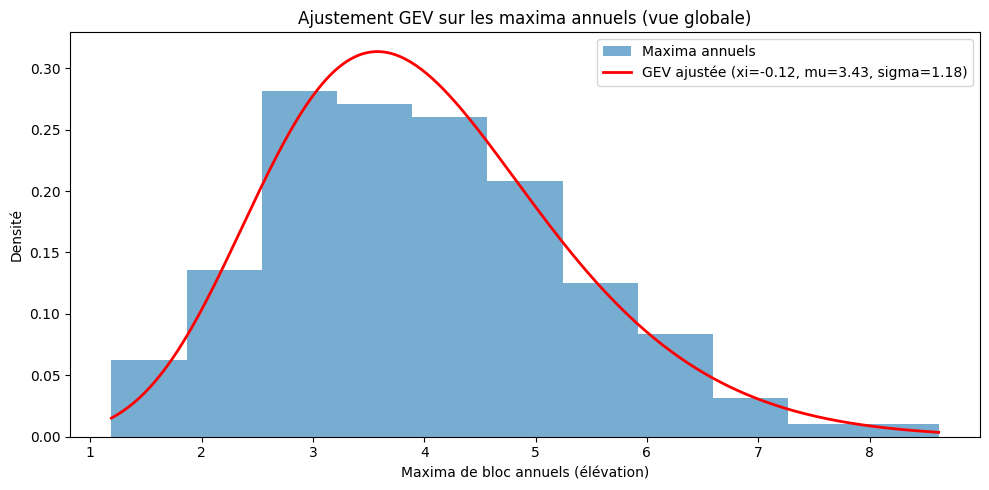

In [21]:
# Diagnostic visuel simple: histogramme des maxima annuels + densité GEV ajustée
x = np.linspace(annual_max.min(), annual_max.max(), 300)
gev_pdf = stats.genextreme.pdf(x, c, loc=mu, scale=sigma)

plt.figure(figsize=(10, 5))

plt.hist(annual_max, bins="auto", density=True, alpha=0.6, label="Maxima annuels")
plt.plot(x, gev_pdf, "r-", lw=2, label=f"GEV ajustée (xi={xi:.2f}, mu={mu:.2f}, sigma={sigma:.2f})")
plt.xlabel("Maxima de bloc annuels (élévation)")
plt.ylabel("Densité")
plt.title("Ajustement GEV sur les maxima annuels (vue globale)")
plt.legend()

plt.tight_layout()
plt.show()



# Estimation des quantiles extrêmes

Ce qui nous permet d'estimer les quantiles extrêmes de la distribution limite, et ainsi d'estimer les niveaux d'élévation correspondant à des périodes de retour de 10 ans, 100 ans, etc.

In [22]:
c, mu, sigma = params_fit_annual
xi = -c
print(f"Paramètres GEV ajustée (max annuels): xi={xi:.4f}, mu={mu:.4f}, sigma={sigma:.4f}")

Paramètres GEV ajustée (max annuels): xi=-0.1185, mu=3.4309, sigma=1.1820


In [23]:
# Estimation des quantiles extrêmes
alphas = [0.1, 0.01, 0.001, 0.0001]  # Probabilité de dépassement pour les périodes de retour
quantiles = stats.genextreme.ppf(1-np.array(alphas), c, loc=mu, scale=sigma)
print("Quantiles extrêmes estimés pour différents périodes de retour:")
for alpha, q in zip(alphas, quantiles):
    print(f"Quantile pour P(X > x) = {1-alpha:.4f}: {q:.2f} m")

Quantiles extrêmes estimés pour différents périodes de retour:
Quantile pour P(X > x) = 0.9000: 5.77 m
Quantile pour P(X > x) = 0.9900: 7.62 m
Quantile pour P(X > x) = 0.9990: 9.01 m
Quantile pour P(X > x) = 0.9999: 10.06 m


In [24]:
# Estimation des quantiles extrêmes à partir de plusieurs modèles
return_periods = np.array([10, 50, 100, 200, 500, 1000, 2000, 5000, 10000])  # années (maxima annuels)
p = 1 - 1 / return_periods  # niveau de probabilité associé
quantiles_gev_blocks = stats.genextreme.ppf(p, c, loc=mu, scale=sigma)

# Quantiles empiriques (sur maxima annuels): très instables pour grands T
empirical_quantiles = np.quantile(annual_max, p)

# Quantiles obtenus par les distributions ajustées (sur données journalières shiftées)
lognorm_quantiles = stats.lognorm.ppf(
    p,
    fit_distribution["lognormale"][0],
    loc=fit_distribution["lognormale"][1],
    scale=fit_distribution["lognormale"][2],
) + SHIFT_SEINE
gamma_quantiles = stats.gamma.ppf(
    p,
    fit_distribution["gamma"][0],
    loc=fit_distribution["gamma"][1],
    scale=fit_distribution["gamma"][2],
) + SHIFT_SEINE
gev_quantiles_daily = stats.genextreme.ppf(
    p,
    fit_distribution["GEV"][0],
    loc=fit_distribution["GEV"][1],
    scale=fit_distribution["GEV"][2],
)

In [25]:
# Quantiles de la mixture - prend un peu de temps
mixture_kde_gpd_quantiles = [utils.mixture_kde_gpd_quantile(1 - 1 / T, params_mixture_kde_gpd) for T in return_periods]

In [26]:
# Tableau récapitulatif des quantiles extrêmes
results_df = pd.DataFrame({
    "Période de retour (années)": return_periods,
    "GEV sur maxima annuels (bloc)": quantiles_gev_blocks,
    "Quantile empirique (max annuels)": empirical_quantiles,
    "Lognormale (sur journalier, shift)": lognorm_quantiles,
    "Gamma (sur journalier, shift)": gamma_quantiles,
    "GEV (sur journalier)": gev_quantiles_daily,
    "Mixture KDE + GPD (POT)": mixture_kde_gpd_quantiles,
})
results_df.set_index("Période de retour (années)", inplace=True)
results_df.style.format("{:.2f}")

,GEV sur maxima annuels (bloc),Quantile empirique (max annuels),"Lognormale (sur journalier, shift)","Gamma (sur journalier, shift)",GEV (sur journalier),Mixture KDE + GPD (POT)
Période de retour (années),,,,,,
10,5.77,5.83,2.35,2.37,2.26,2.46
50,7.12,6.90,3.11,3.05,3.19,4.00
100,7.62,7.24,3.42,3.31,3.61,4.58
200,8.08,7.70,3.72,3.56,4.05,5.12
500,8.63,8.25,4.11,3.87,4.67,5.78
1000,9.01,8.44,4.40,4.09,5.16,6.24
2000,9.35,8.53,4.69,4.31,5.68,6.67
5000,9.77,8.58,5.07,4.59,6.40,7.18
10000,10.06,8.60,5.35,4.80,6.97,7.54


Le quantile empirique fonctionne bien au début lorsqu'il y a beaucoup de données, mais il sature très vite. 
On rappelle qu'avec environ 130 ans de données, passée 50 ans de période de retour, on n'a plus que 2 ou 3 données pour estimer le quantile empirique, ce qui n'est pas du tout fiable.

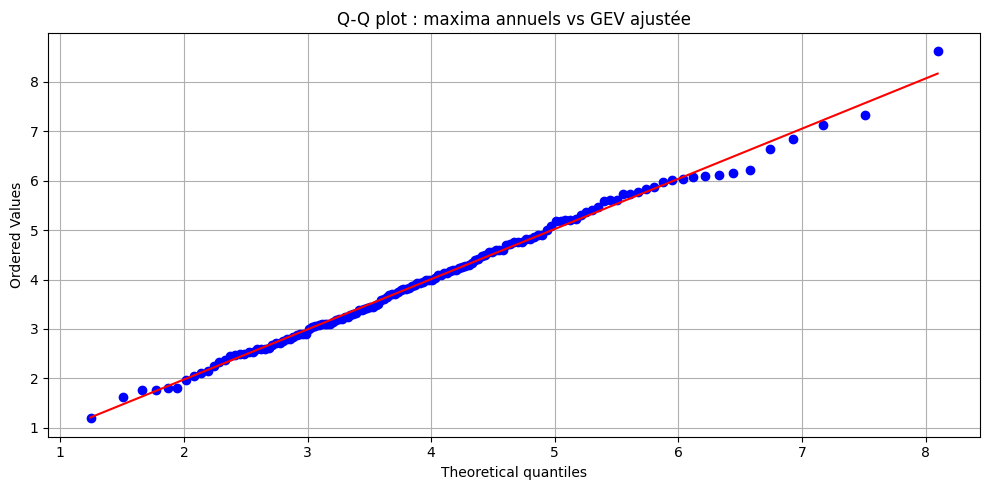

In [27]:
# Q-Q plot: maxima annuels vs GEV ajustée
plt.figure(figsize=(10, 5))
stats.probplot(
    annual_max,
    dist=stats.genextreme(c, loc=mu, scale=sigma),
    plot=plt,
 )

plt.title("Q-Q plot : maxima annuels vs GEV ajustée")
plt.grid(True)
plt.tight_layout()
plt.show()

On remarque que le QQ plot est très linéaire, ce qui suggère que les maxima annuels suivent bien une distribution de Gumbel avec les paramètres estimés.

# 5) Saisonnalité (diagnostic simple)

Étudions l'effet de saisonnalité qui est éventuellement à retirer des données. 

a (niveau moyen) = 1.4554
Amplitude saisonnière = 0.5700 m
Phase = -0.8286 rad


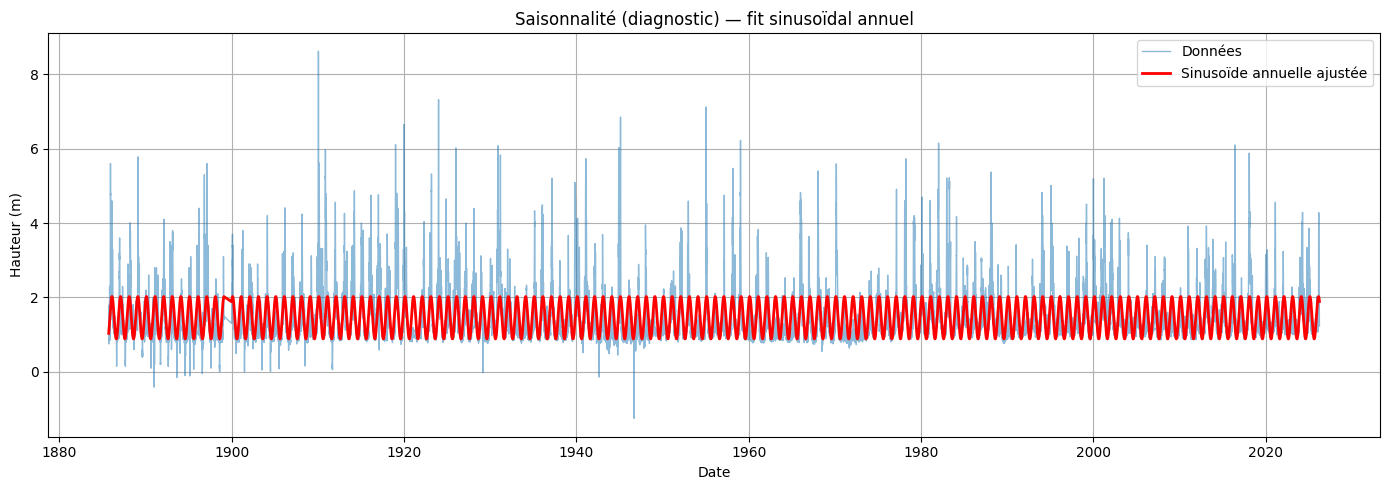

In [28]:
# Fit sinusoïdal (période annuelle) pour capturer une saisonnalité sur l'élévation
t_days = (seine["Date"] - seine["Date"].min()).dt.total_seconds() / 86400.0
y = seine["Hauteur"].values

T = 365.2425  # période annuelle en jours
omega = 2 * np.pi / T

# Modèle: y(t) = a + b*sin(omega*t) + d*cos(omega*t)
X = np.column_stack([np.ones_like(t_days), np.sin(omega * t_days), np.cos(omega * t_days)])
a, b, d = np.linalg.lstsq(X, y, rcond=None)[0]

seasonal_effect = b * np.sin(omega * t_days) + d * np.cos(omega * t_days)
seine["seasonal_effect"] = seasonal_effect
seine["seasonal_fit"] = a + seasonal_effect
seine["elevation_deseasonalized"] = seine["Hauteur"] - seasonal_effect

amplitude = np.sqrt(b**2 + d**2)
phase = np.arctan2(d, b)  # y = a + A*sin(omega*t + phase)

print(f"a (niveau moyen) = {a:.4f}")
print(f"Amplitude saisonnière = {amplitude:.4f} m")
print(f"Phase = {phase:.4f} rad")

plt.figure(figsize=(14, 5))
plt.plot(seine["Date"], seine["Hauteur"], label="Données", alpha=0.5, lw=1)
plt.plot(seine["Date"], seine["seasonal_fit"], color="red", lw=2, label="Sinusoïde annuelle ajustée")
plt.xlabel("Date")
plt.ylabel("Hauteur (m)")
plt.title("Saisonnalité (diagnostic) — fit sinusoïdal annuel")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("fig_05_saisonnalite.png", dpi=200)
plt.show()

# Conclusion (à remettre)

**Synthèse.** Sur ces données, un ajustement GEV sur les maxima annuels fournit un estimateur $\hat\xi<0$ (convention EVT), suggérant un comportement de type **Weibull** dans ce modèle de maxima de blocs. Les quantiles de grandes périodes de retour sont ensuite comparés entre plusieurs approches (paramétriques sur le journalier, maxima annuels, et POT via KDE+GPD).

**Limites / hypothèses importantes.**
- **Dépendance temporelle** : les hauteurs journalières sont autocorrélées ; pour POT, cela justifie en général un *declustering* avant l’ajustement GPD.
- **Stationnarité** : tendances (ouvrages, aménagements), changements de régime, et **saisonnalité** peuvent biaiser $\xi$ et les quantiles de retour ; une EVT non-stationnaire peut être nécessaire.
- **Choix du seuil $u$ (POT)** : il doit être validé (stabilité de $\hat\xi$, mean residual life plot, etc.).
- **Incertitude** : les périodes de retour élevées (ex. 1000–10 000 ans) extrapolent fortement ; il faut idéalement des intervalles de confiance (bootstrap/profil de vraisemblance).

**À améliorer si demandé** : diagnostics POT (stabilité en fonction de $u$), intervalles de confiance, et comparaison “maxima annuels” vs “maxima mensuels” avec interprétation cohérente des périodes de retour.